# Attempting to Model NGC6569 with PyfalcON


In [1]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 200  # Set to 100MB or whatever you need

from IPython.display import HTML

import pandas as pd

import pyfalcon

In [ ]:
import astropy.coordinates as coord
import astropy.units as u
from astropy.constants import G
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms

import agama

import importlib
import sys
from pathlib import Path

from time import time

START_DIR = Path.cwd().resolve()
NGC6569_DIR = next(
    (path for path in (START_DIR, START_DIR / "ngc6569", START_DIR / "joe's_Code" / "ngc6569")
     if (path / "milkyway").is_dir()),
    None,
)
if NGC6569_DIR is None:
    raise FileNotFoundError("Could not locate joe's_Code/ngc6569/milkyway from the current working directory")

DATA_DIR = NGC6569_DIR / "data"
OUTPUT_DIR = NGC6569_DIR / "output"
MILKYWAY_DIR = NGC6569_DIR / "milkyway"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if str(NGC6569_DIR) not in sys.path:
    sys.path.insert(0, str(NGC6569_DIR))

from leap_frog import kdk_leapfrog_TD
from leap_frog import kdk_leapfrog
from leap_frog import kdk_leapfrog_to_disk
from snapshot_store import SnapshotBinaryReader

#from leap_frog_hdf5 import kdk_leapfrog_hdf5, load_simulation_hdf5

In [3]:
# default Astropy Galactocentric frame parameters to the values adopted in Astropy v4.0:
_ = coord.galactocentric_frame_defaults.set('v4.0')

# set Agama units 
# working units: 1 Msun, 1 kpc, 1 km/s
agama.setUnits(length=1*u.kpc, velocity=1*u.km/u.s, mass=1*u.Msun)
print("Newton G in Agama units,",agama.G)

# Check the current unit system
print("Current Agama units:")
print(f"Length unit: {agama.getUnits()['length']}")
print(f"Velocity unit: {agama.getUnits()['velocity']}")  
print(f"Time unit: {agama.getUnits()['time']}")
print(f"Mass unit: {agama.getUnits()['mass']}")

agama_time_unit = agama.getUnits()["time"]
print(agama_time_unit)

Newton G in Agama units, 4.30091727067736e-06
Current Agama units:
Length unit: 1.0 kpc
Velocity unit: 1.0 km / s
Time unit: 977.792221683525 Myr
Mass unit: 1.0 solMass
977.792221683525 Myr


In [4]:
# Use the Hunter rotating potential 
pot_ext = agama.Potential(str(MILKYWAY_DIR / "MWPotentialHunter24_full.ini")) 
pot_rot = agama.Potential(str(MILKYWAY_DIR / "MWPotentialHunter24_rotating.ini")) 
pot_bovy = agama.Potential(str(MILKYWAY_DIR / "MWPotential2014.ini")) 

pot_use = pot_rot

In [5]:
# NG6569 coordinates 

c = coord.SkyCoord(ra = 273.412*u.degree, dec = -31.827*u.degree,
                        distance=(10.5)*u.kpc,
                        pm_ra_cosdec= -4.125*u.mas/u.yr,
                        pm_dec= -7.354*u.mas/u.yr,
                        radial_velocity= -49.82*u.km/u.s)

# transform to galactic centeric 
c_gc = c.transform_to(coord.Galactocentric).data
print(c_gc._differentials)

{'s': <CartesianDifferential (d_x, d_y, d_z) in kpc mas / (rad yr)
    (-6.71192364, -36.78139749, 5.0482508)>}


In [6]:
# creat phase space object
w0 = gd.PhaseSpacePosition(c_gc)
print("initial position :", w0.pos)
print("initial velocity :", w0.vel)
print("Need to convert velocity to km/s")

pos_0 = np.r_[w0.pos.x.value, w0.pos.y.value, w0.pos.z.value]
vel_0 = np.r_[w0.vel.d_x.to(u.km/u.s).value, 
              w0.vel.d_y.to(u.km/u.s).value,
              w0.vel.d_z.to(u.km/u.s).value]
print("position", pos_0) 
print("velocity", vel_0) 

initial position : (2.30319138, 0.08753024, -1.22751023) kpc
initial velocity : (-6.71192364, -36.78139749, 5.0482508) kpc mas / (rad yr)
Need to convert velocity to km/s
position [ 2.30319138  0.08753024 -1.22751023]
velocity [ -31.81767579 -174.36112841   23.93108381]


In [7]:
# integrate orbit 
tfin= -1000*u.Myr
nt=2000
t_eval = np.linspace(0, tfin, nt)
t_scipy = t_eval.to(u.Gyr).value/agama_time_unit.to(u.Gyr).value
t_scipy

array([ 0.00000000e+00, -5.11611888e-04, -1.02322378e-03, ...,
       -1.02168894e+00, -1.02220055e+00, -1.02271217e+00], shape=(2000,))

In [8]:
def rhs(t,state): 
    
    pos = state[:3]
    vel = state[3:]

    acc = pot_use.force(pos, t=t)
    return np.r_[vel, acc] 

# integrate with solve_ivp
from scipy.integrate import solve_ivp

state_0 = np.r_[pos_0, vel_0] 
print(state_0, state_0.shape)

t_span = (0, t_scipy[-1]) 
sol = solve_ivp(rhs, t_span, state_0, t_eval =t_scipy, rtol=1e-10, atol=1e-10)
orbit = sol["y"]

[ 2.30319138e+00  8.75302429e-02 -1.22751023e+00 -3.18176758e+01
 -1.74361128e+02  2.39310838e+01] (6,)


In [9]:
x = orbit[0,:]
y = orbit[1,:]
z = orbit[2,:]
vx = orbit[3,:]
vy = orbit[4,:]
vz = orbit[5,:]

In [10]:
# Define the parameters for your King model
W0_value = 7.0  # Example W0 value
# create an isolated star cluster
r_scale = 1/1000
m = 2.3*1e5*(2)
pot_sat = agama.Potential(type='king', W0=W0_value, scaleRadius=r_scale, mass=m)
df_sat = agama.DistributionFunction(type='quasispherical', potential=pot_sat)
Nbody = 150000
xv, mass = agama.GalaxyModel(pot_sat, df_sat).sample(Nbody)

r_agama = np.sqrt(xv[:,0]**2 + xv[:,1]**2 + xv[:,2]**2) 
v_agama = np.sqrt(xv[:,3]**2 + xv[:,4]**2 + xv[:,5]**2) 

print("Agama G:", agama.G)

cluster_data = np.c_[mass, xv]
cluster_data.shape
np.savetxt(DATA_DIR / "cluster_data.txt", cluster_data)

Agama G: 4.30091727067736e-06


In [11]:
pos_0 = np.r_[x[-1], y[-1], z[-1]]
vel_0 = np.r_[vx[-1], vy[-1], vz[-1]]
print(pos_0)
print(vel_0) 

[1.50593945 1.7545462  0.35122484]
[ 162.31501297   -6.06585487 -121.4713529 ]


In [12]:
print("make this a function")

def shift_to_gc(xv, pos_0, vel_0): 

    x = xv[:,0] + pos_0[0]
    y = xv[:,1] + pos_0[1]
    z = xv[:,2] + pos_0[2]

    vx = xv[:,3] + vel_0[0]
    vy = xv[:,4] + vel_0[1]
    vz = xv[:,5] + vel_0[2]


    print("checks")
    print(np.mean(x), np.mean(y), np.mean(z))
    print(pos_0)


    print(np.mean(vx), np.mean(vy), np.mean(vz))
    print(vel_0)

    return np.column_stack((x, y, z)), np.column_stack((vx, vy, vz))


make this a function


In [13]:
# pos_0 = np.column_stack((x, y, z))
# vel_0 = np.column_stack((vx, vy, vz))
# vel_0.shape

pos_0 , vel_0 = shift_to_gc(xv, pos_0, vel_0)

checks
1.5059357752170017 1.7545418295748816 0.3512342605814525
[1.50593945 1.7545462  0.35122484]
162.30556595788744 -6.057680831128618 -121.45911832643652
[ 162.31501297   -6.06585487 -121.4713529 ]


In [14]:
time_unit=u.kpc.to(u.km)*u.s.to(u.Gyr)
time_unit

0.9777922216807892

In [15]:
tmax = -tfin.to(u.Gyr).value/time_unit
print("maximum time", tmax)
print(t_scipy[-1])

maximum time 1.022712165045695
-1.0227121650428335


In [16]:
kmax=16
tau = 2**(-kmax)*time_unit
print("time step:", tau) 
nt=int(tmax/tau) + 1
print("number of time steps:", nt)

eps = 1/1000  # II 
eps = .1/1000 # I 
eps_power = -4
eps = (2**eps_power)/1000
print("softening length:", eps) 

time step: 1.4919925257580401e-05
number of time steps: 68547
softening length: 6.25e-05


In [17]:
downsample=20
#filename="ngc_6569_runI"
#nt=1000

## Cache the full main KDK simulation

In [18]:
## Cache the full main KDK simulation
# Snapshots stream straight to a binary file as they're produced (kdk_leapfrog_to_disk /
# snapshot_store.py), so the run never needs to hold all snapshots in memory at once,
# and any snapshots already flushed survive a kernel crash instead of being lost.
import hashlib
import json

USE_MAIN_KDK_CACHE = True
MAIN_KDK_CACHE_DIR = OUTPUT_DIR / "main_kdk_cache"
MAIN_KDK_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def main_potential_path(potential):
    """Return the source file for the potential currently selected as pot_use."""
    candidates = [
        (pot_ext, MILKYWAY_DIR / "MWPotentialHunter24_full.ini"),
        (pot_rot, MILKYWAY_DIR / "MWPotentialHunter24_rotating.ini"),
        (pot_bovy, MILKYWAY_DIR / "MWPotential2014.ini"),
    ]
    for candidate, path in candidates:
        if potential is candidate:
            return path
    raise ValueError("pot_use is not one of the notebook potentials; provide its source file explicitly")

def _update_hash_with_array(hasher, name, values):
    """Hash an array's name, shape, dtype, and values without changing it."""
    values = np.ascontiguousarray(values)
    hasher.update(name.encode("utf-8"))
    hasher.update(str(values.shape).encode("ascii"))
    hasher.update(values.dtype.str.encode("ascii"))
    hasher.update(memoryview(values).cast("B"))

def _main_kdk_cache_key(pos, vel, particle_mass, settings, potential_path):
    """Build a cache key from all main-run initial conditions and numerical settings."""
    hasher = hashlib.sha256(b"ngc6569-main-kdk-cache-v2")  # v2: streamed binary format, not pickle.
    _update_hash_with_array(hasher, "pos", pos)
    _update_hash_with_array(hasher, "vel", vel)
    _update_hash_with_array(hasher, "mass", particle_mass)
    hasher.update(json.dumps(settings, sort_keys=True).encode("utf-8"))
    hasher.update(Path(potential_path).read_bytes())  # Potential changes must invalidate the cache.
    return hasher.hexdigest()[:20]

def _validate_main_kdk_snapshots(snapshots, n_particles, expected_count=None):
    """Reject empty, incomplete, or incompatible cached runs before downstream analysis uses them."""
    if len(snapshots) == 0:
        raise ValueError("cached simulation has no snapshots")
    if expected_count is not None and len(snapshots) < expected_count:
        raise ValueError(
            f"cache has {len(snapshots)} of {expected_count} expected snapshots "
            "(likely an interrupted run)"
        )
    required = {"time", "pos", "vel", "phi"}
    for snapshot in (snapshots[0], snapshots[-1]):
        if not required.issubset(snapshot):
            raise ValueError("cached snapshot is missing required fields")
        if np.shape(snapshot["pos"]) != (n_particles, 3):
            raise ValueError("cached positions have the wrong shape")
        if np.shape(snapshot["vel"]) != (n_particles, 3):
            raise ValueError("cached velocities have the wrong shape")
        if np.shape(snapshot["phi"]) != (n_particles,):
            raise ValueError("cached potentials have the wrong shape")

def run_main_kdk_with_cache(
    potential, pos, vel, particle_mass, nt_run, tau_run, G_run, eps_run,
    time_unit_run, downsample_run, potential_path, last_snapshot=False, use_cache=True,
):
    """Load a matching cached run or execute and stream the main KDK run to disk.

    Note: if a previous attempt was interrupted partway through, this reruns the
    simulation from scratch rather than resuming from the last flushed snapshot.
    """
    settings = {
        "nt": int(nt_run),
        "tau": float(tau_run),
        "G": float(G_run),
        "eps": float(eps_run),
        "time_unit": float(time_unit_run),
        "downsample": int(downsample_run),
        "last_snapshot": bool(last_snapshot),
    }
    cache_key = _main_kdk_cache_key(pos, vel, particle_mass, settings, potential_path)
    cache_path = MAIN_KDK_CACHE_DIR / f"main_kdk_{cache_key}.bin"
    expected_count = nt_run // downsample_run + 1
    if last_snapshot and nt_run % downsample_run != 0:
        expected_count += 1

    if use_cache and cache_path.is_file():
        try:
            snapshots = SnapshotBinaryReader(cache_path)
            _validate_main_kdk_snapshots(snapshots, len(particle_mass), expected_count)
            size_gib = cache_path.stat().st_size / 1024**3
            print(f"main KDK cache hit: {cache_path.name} ({size_gib:.2f} GiB, {len(snapshots)} snapshots)")
            return snapshots, cache_path, True
        except (OSError, FileNotFoundError, ValueError) as error:
            print(f"main KDK cache invalid; rerunning simulation: {error}")

    print(f"main KDK cache miss: {cache_path.name}")
    snapshots = kdk_leapfrog_to_disk(
        potential, pos, vel, particle_mass, nt_run, tau_run, G_run, eps_run,
        time_unit_run, downsample_run, cache_path, last_snapshot=last_snapshot,
    )
    _validate_main_kdk_snapshots(snapshots, len(particle_mass), expected_count)

    return snapshots, cache_path, False


In [19]:
t1 = time()
sim_data, MAIN_KDK_CACHE_PATH, MAIN_KDK_CACHE_HIT = run_main_kdk_with_cache(
    pot_use, pos_0, vel_0, mass, nt, tau, agama.G, eps,
    time_unit, downsample,
    potential_path=main_potential_path(pot_use),
    last_snapshot=False,
    use_cache=USE_MAIN_KDK_CACHE,
)
t2 = time()
source = "cache" if MAIN_KDK_CACHE_HIT else "simulation"
print(f"main KDK {source} time: {t2-t1:.2f} s ({(t2-t1)/60:.2f} min)")

main KDK cache miss: main_kdk_6d095b39bb3fba72ed97.pkl
main KDK cache written: main_kdk_6d095b39bb3fba72ed97.pkl (26.82 GiB)
main KDK simulation time: 8672.06 s (144.53 min)


In [20]:
from bound_funcs import get_bound_particles

bound_data = get_bound_particles(sim_data, mass)

In [21]:
def trajectories(bound_data, sim_data): 
    """
    Extract time evolution trajectories of bound cluster properties from simulation data.
    
    This function processes the output from bound particle tracking to create clean
    time series arrays for analysis and plotting of cluster evolution.
    
    Parameters:
    -----------
    bound_data : list of dict
        List of dictionaries containing bound particle data at each timestep.
        Each dictionary should contain keys: 'total mass', 'total energy', 'pos', 'vel'
    sim_data : list of dict
        List of dictionaries containing simulation data at each timestep.
        Each dictionary should contain key: 'time'
        
    Returns:
    --------
    dict : Dictionary containing trajectory arrays
        'mass' : array, shape (n,) - Total mass of bound particles vs time
        'energy' : array, shape (n,) - Total energy of bound particles vs time  
        'time' : array, shape (n,) - Time array
        'pos' : array, shape (n, 3) - Center of mass position vs time
        'vel' : array, shape (n, 3) - Center of mass velocity vs time

    """
    
    n = len(bound_data)
    
    # Validate input lengths match
    if len(sim_data) != n:
        raise ValueError(f"Length mismatch: bound_data has {n} entries, sim_data has {len(sim_data)}")
    
    # Initialize trajectory arrays
    time_array = np.zeros(n)
    mass_traj = np.zeros(n)
    energy_traj = np.zeros(n)
    r_traj = np.zeros((n, 3))
    d_traj = np.zeros(n)
    v_traj = np.zeros((n, 3))
    
    # Extract data for each timestep
    for i in range(n): 
        # Extract bound particle properties
        mass_traj[i] = bound_data[i]["total mass"]
        energy_traj[i] = bound_data[i]["total energy"]
        r_traj[i, :] = bound_data[i]["pos"]
        v_traj[i, :] = bound_data[i]["vel"]
        d_traj[i] = np.linalg.norm(r_traj[i,:]) 
        
        # Extract time from simulation data
        time_array[i] = sim_data[i]["time"] 
    
    # Package results into dictionary
    traj = {
        'mass': mass_traj,
        'energy': energy_traj,
        'time': time_array,
        'pos': r_traj,
        'vel': v_traj,
        'distance': d_traj
    }
    
    return traj

traj = trajectories(bound_data, sim_data)

In [22]:
# get time array 
time_array=[]
for i in range(len(sim_data)): 

    t = sim_data[i]["time"]
    time_array.append(t*1000) 

time_array=np.array(time_array)    


In [23]:
def get_tidal_data(traj, pot_ext): 

    pos = traj["pos"]
    n=pos.shape[0]

    tidal = np.zeros((n,3))
    max_tidal = np.zeros(n)

    for i in range(n): 

        H = np.zeros((3, 3))
        
        hess = pot_ext.eval(pos[i,:], der=True)
    
    
        # Upper triangular indices
        triu_indices = np.triu_indices(3)
        H[triu_indices] = hess
    
        # Make symmetric
        H = H + H.T - np.diag(np.diag(H))

        tidal[i,:] = np.linalg.eigvals(H)

        max_tidal[i] = np.max(tidal[i,:]) 

    return tidal, max_tidal 

tidal, max_tidal = get_tidal_data(traj, pot_ext)


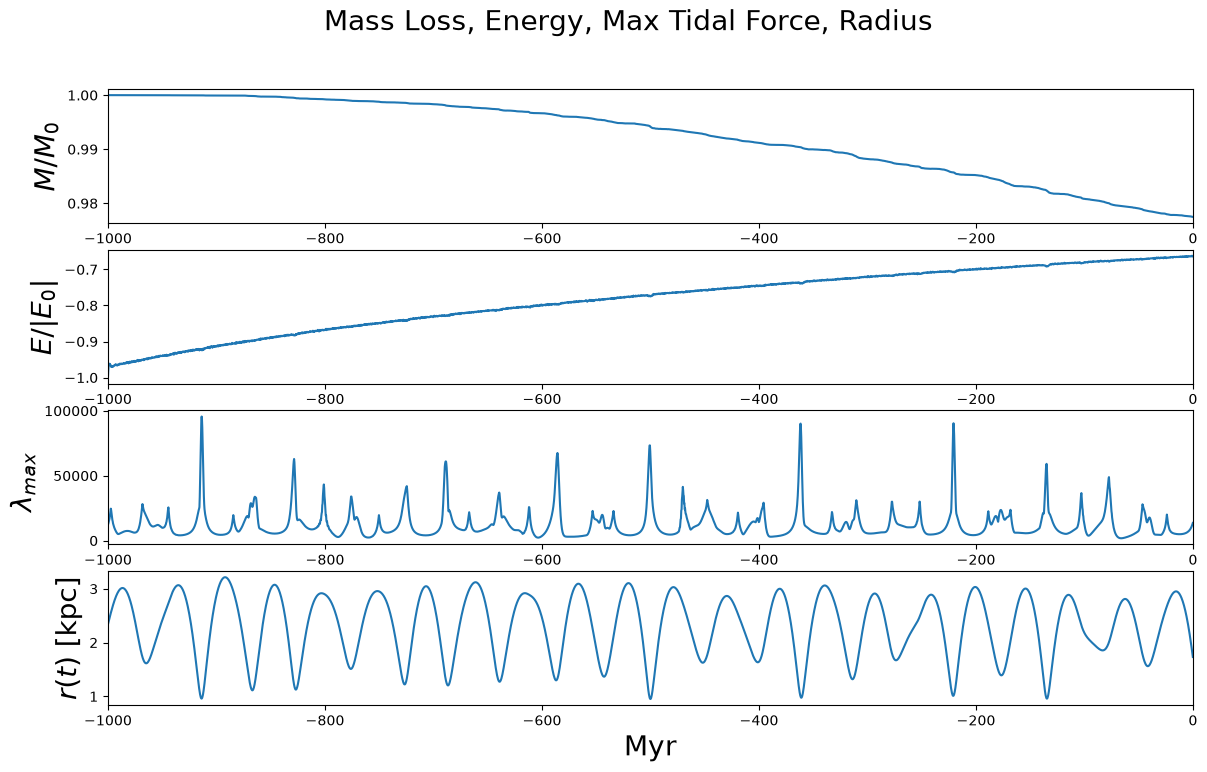

In [24]:
max_t=np.max(max_tidal)

fig = plt.figure(figsize=(14, 8 ))
fig.suptitle('Mass Loss, Energy, Max Tidal Force, Radius ', size=20)
ax = fig.add_subplot(411)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$M/M_0$", size=20) 
#ax.set_xlabel("Myr", size=20)

M0=traj["mass"][0]
ax.plot(time_array+tfin.value, traj["mass"]/M0)


ax = fig.add_subplot(412)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$E/|E_0|$", size=20) 
#ax.set_xlabel("Myr", size=20) 
E = traj["energy"]
ax.plot(time_array+tfin.value, E/np.abs(E[0])) 


ax = fig.add_subplot(413)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$\lambda_{max}$ ", size=20) 
ax.set_xlabel("Myr", size=20) 
ax.plot(time_array + tfin.value, max_tidal)


ax = fig.add_subplot(414)
ax.set_xlim(tfin.value, 0)
#ax.set_xlim(tfin.value, -900)
ax.set_ylabel(r"$r(t)$ [kpc]", size=20) 
ax.set_xlabel("Myr", size=20) 
ax.plot(time_array + tfin.value, traj["distance"])

fig.savefig(OUTPUT_DIR / "6570_ml_II.pdf") 

# print("Maybe add distance from galactic center." ) 
# print("How does tidal stripping compare at large tidal tensor versus Particle Spray method." ) 
# print("why is there a dip in energy right before an increase?" )


## Convert simulation output to observable coordinates

These cells transform Galactocentric positions and velocities into ICRS sky coordinates using the same Astropy v4.0 Galactocentric frame adopted above. The output includes heliocentric distance, Galactocentric radius, proper motions, and line-of-sight radial velocity.

In [25]:
## Observable-coordinate helpers
# The simulation stores phase-space points in a Galactocentric Cartesian frame:
# positions are x, y, z in kpc and velocities are vx, vy, vz in km/s.
def galactocentric_to_observables(pos, vel):
    """Convert Galactocentric phase-space arrays into an observable pandas table."""
    # Convert inputs to numeric arrays and allow either one object (3,) or many objects (N, 3).
    pos = np.asarray(pos, dtype=float)
    vel = np.asarray(vel, dtype=float)
    pos = np.atleast_2d(pos)
    vel = np.atleast_2d(vel)

    # Each position must have a matching velocity, and both must carry three Cartesian components.
    if pos.shape != vel.shape or pos.shape[1] != 3:
        raise ValueError("pos and vel must have matching shape (N, 3)")

    # Attach Astropy units before building the Galactocentric coordinate object.
    # The frame defaults are the Astropy v4.0 Galactocentric parameters set earlier in the notebook.
    galactocentric = coord.SkyCoord(
        x=pos[:, 0] * u.kpc,
        y=pos[:, 1] * u.kpc,
        z=pos[:, 2] * u.kpc,
        v_x=vel[:, 0] * u.km / u.s,
        v_y=vel[:, 1] * u.km / u.s,
        v_z=vel[:, 2] * u.km / u.s,
        representation_type="cartesian",
        differential_type="cartesian",
        frame=coord.Galactocentric(),
    )
    # Transform to the observer's sky frame so RA/Dec, heliocentric distance, proper motion,
    # and line-of-sight velocity are all computed consistently from the same 6D point.
    icrs = galactocentric.transform_to(coord.ICRS())

    # distance_kpc is Sun-to-object distance; galactocentric_radius_kpc is distance from the Galactic center.
    # pm_ra_cosdec_masyr includes the cos(dec) factor, which is the standard catalog convention.
    return pd.DataFrame({
        "ra_deg": icrs.ra.to_value(u.deg),
        "dec_deg": icrs.dec.to_value(u.deg),
        "distance_kpc": icrs.distance.to_value(u.kpc),
        "galactocentric_radius_kpc": np.linalg.norm(pos, axis=1),
        "pm_ra_cosdec_masyr": icrs.pm_ra_cosdec.to_value(u.mas / u.yr),
        "pm_dec_masyr": icrs.pm_dec.to_value(u.mas / u.yr),
        "radial_velocity_kms": icrs.radial_velocity.to_value(u.km / u.s),
    })

def snapshot_to_observables(snapshot, particle_mass=None, bound_mask=None):
    """Convert one N-body snapshot and retain particle metadata for later selections."""
    # Convert every particle in the snapshot from simulation coordinates to observable columns.
    table = galactocentric_to_observables(snapshot["pos"], snapshot["vel"])
    # Preserve a stable particle index so rows can be joined back to simulation arrays if needed.
    table.insert(0, "particle_id", np.arange(len(table)))

    if particle_mass is not None:
        # Broadcast a scalar mass or keep a per-particle mass array, then store it with solar-mass units.
        particle_mass = np.broadcast_to(np.asarray(particle_mass, dtype=float), (len(table),))
        table["particle_mass_Msun"] = particle_mass
    if bound_mask is not None:
        # Mark which particles still belong to the bound remnant at this snapshot.
        bound_mask = np.asarray(bound_mask, dtype=bool)
        if bound_mask.shape != (len(table),):
            raise ValueError("bound_mask must have one value per particle")
        table["bound"] = bound_mask

    return table

def add_sky_offsets(observables, center):
    """Add tangent-plane angular offsets from a reference SkyCoord."""
    # Reconstruct sky positions from the table before measuring angular separation from center.
    sky = coord.SkyCoord(
        ra=observables["ra_deg"].to_numpy() * u.deg,
        dec=observables["dec_deg"].to_numpy() * u.deg,
        frame="icrs",
    )
    # spherical_offsets_to returns local tangent-plane offsets: delta RA*cos(dec) and delta Dec.
    delta_ra_cosdec, delta_dec = center.spherical_offsets_to(sky)
    # Work on a copy so the original observable table is left unchanged unless reassigned.
    result = observables.copy()
    result["delta_ra_cosdec_deg"] = delta_ra_cosdec.to_value(u.deg)
    result["delta_dec_deg"] = delta_dec.to_value(u.deg)
    return result


In [26]:
## Convert the bound-remnant track and the final full-particle snapshot
# First convert the bound-remnant center-of-mass trajectory; this is the model cluster track.
cluster_observables = galactocentric_to_observables(traj["pos"], traj["vel"])
# Store times relative to the present day so the last row should be close to t = 0 Myr.
cluster_observables.insert(
    0,
    "time_from_present_myr",
    traj["time"] * 1000.0 + tfin.to_value(u.Myr),
)

# The last saved snapshot is the closest available model output to the present day.
# This table keeps all particles, plus mass and bound/unbound labels for later cuts.
final_snapshot_observables = snapshot_to_observables(
    sim_data[-1],
    particle_mass=mass,
    bound_mask=bound_data[-1]["bound"],
)
# Convert the snapshot timestamp from Gyr to Myr and shift by tfin to match the track convention.
final_snapshot_time_myr = sim_data[-1]["time"] * 1000.0 + tfin.to_value(u.Myr)

# Center sky-density maps on the simulated bound remnant, not on a hard-coded catalog position.
# Using the final track row keeps the sky offsets internally consistent with this simulation.
final_center = coord.SkyCoord(
    ra=cluster_observables.iloc[-1]["ra_deg"] * u.deg,
    dec=cluster_observables.iloc[-1]["dec_deg"] * u.deg,
    frame="icrs",
)
# Add local tangent-plane offsets in degrees for compact plotting around the cluster center.
final_snapshot_observables = add_sky_offsets(final_snapshot_observables, final_center)

# Save reusable theory-to-observation catalogs for later density and selection analyses.
cluster_observables.to_csv(OUTPUT_DIR / "NGC6569_cluster_track_observables.csv", index=False)
final_snapshot_observables.to_csv(OUTPUT_DIR / "NGC6569_final_snapshot_observables.csv", index=False)

print(f"Final saved snapshot time relative to present: {final_snapshot_time_myr:.3f} Myr")
display(cluster_observables.tail(1))
display(final_snapshot_observables.head())


Final saved snapshot time relative to present: -0.098 Myr


,time_from_present_myr,ra_deg,dec_deg,distance_kpc,galactocentric_radius_kpc,pm_ra_cosdec_masyr,pm_dec_masyr,radial_velocity_kms
3427,-0.098256,254.698294,-27.552079,7.066628,1.732052,2.149425,-2.961903,-15.691031


,particle_id,ra_deg,dec_deg,distance_kpc,galactocentric_radius_kpc,pm_ra_cosdec_masyr,pm_dec_masyr,radial_velocity_kms,particle_mass_Msun,bound,delta_ra_cosdec_deg,delta_dec_deg
0,0,254.667895,-27.530709,7.064620,1.736293,2.273439,-3.031074,-19.405282,2.336095,True,-0.026956,0.021367
1,1,254.698284,-27.539990,7.065331,1.732972,2.259751,-2.953277,-26.516743,2.336095,True,-0.000009,0.012089
2,2,254.709199,-27.568320,7.069735,1.729101,2.481036,-2.935207,-27.002585,2.336095,True,0.009666,-0.016242
3,3,254.689875,-27.546554,7.066955,1.732749,1.938862,-3.147666,-15.442635,2.336095,True,-0.007464,0.005524
4,4,254.625878,-27.628881,7.063401,1.738948,2.160914,-2.739222,-16.652019,2.336095,True,-0.064158,-0.076821


ra_deg                                                             \
          count        mean        std         min         25%         50%   
bound                                                                        
False    3377.0  261.252320  15.142663  240.704408  245.988838  259.421987   
True   146623.0  254.698294   0.038278  253.985909  254.681843  254.698292   

                                dec_deg             ... pm_dec_masyr  \
              75%         max     count       mean  ...          75%   
bound                                               ...                
False  277.861197  287.391732    3377.0 -30.404823  ...    -2.488354   
True   254.714721  255.501555  146623.0 -27.552074  ...    -2.826808   

                radial_velocity_kms                                    \
            max               count       mean        std         min   
bound                                                                   
False  0.763311              3377.0  21.585618  56.988010 -180.926784   
True  -2.188108            146623.0 -15.691025   6.837912  -42.340088   

                                                    
             25%        50%        75%         max  
bound                                               
False -19.978547   0.948544  66.284461  214.949191  
True  -20.204841 -15.699469 -11.179171   11.348439  

[2 rows x 48 columns]

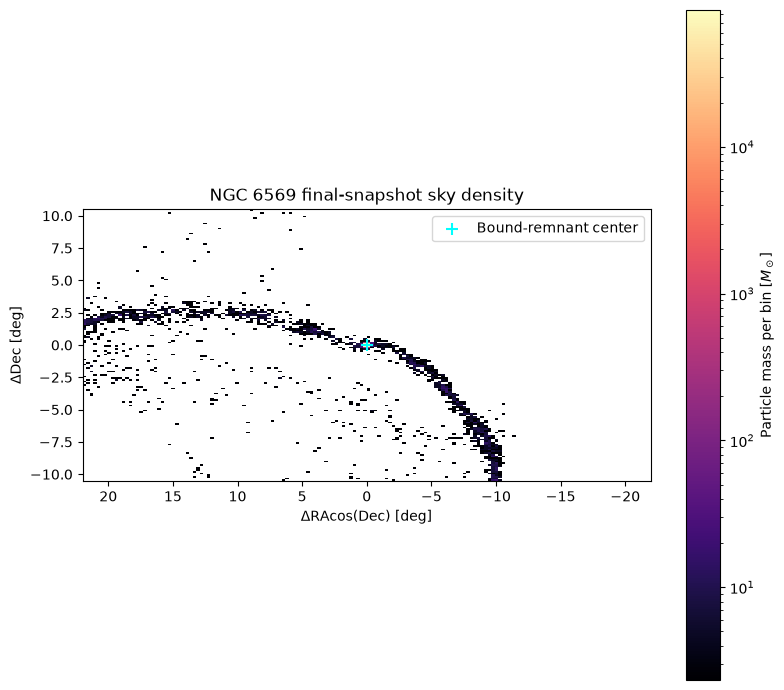

In [27]:
## Present-day observable density map and summary statistics
def plot_sky_density(observables, bins=160, display_percentile=99.5):
    """Plot projected particle mass or particle counts in remnant-centered sky coordinates."""
    x = observables["delta_ra_cosdec_deg"].to_numpy()
    y = observables["delta_dec_deg"].to_numpy()
    finite = np.isfinite(x) & np.isfinite(y)
    if not np.any(finite):
        raise ValueError("No finite sky positions are available to plot")

    x_limit = max(np.nanpercentile(np.abs(x[finite]), display_percentile), 1e-6)
    y_limit = max(np.nanpercentile(np.abs(y[finite]), display_percentile), 1e-6)
    weights = None
    colorbar_label = "Particles per bin"
    if "particle_mass_Msun" in observables:
        weights = observables.loc[finite, "particle_mass_Msun"].to_numpy()
        colorbar_label = r"Particle mass per bin [$M_\odot$]"

    fig, ax = plt.subplots(figsize=(8, 7))
    density = ax.hist2d(
        x[finite],
        y[finite],
        bins=bins,
        range=[[-x_limit, x_limit], [-y_limit, y_limit]],
        weights=weights,
        norm=mpl.colors.LogNorm(),
        cmap="magma",
    )
    ax.scatter(0.0, 0.0, marker="+", s=80, linewidth=1.5, color="cyan", label="Bound-remnant center")
    ax.set_xlabel(r"$\Delta \mathrm{RA}\cos(\mathrm{Dec})$ [deg]")
    ax.set_ylabel(r"$\Delta \mathrm{Dec}$ [deg]")
    ax.set_title("NGC 6569 final-snapshot sky density")
    ax.invert_xaxis()  # Astronomical convention: RA increases toward the left.
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best")
    fig.colorbar(density[3], ax=ax, label=colorbar_label)
    fig.tight_layout()
    return fig, ax

observable_columns = [
    "ra_deg", "dec_deg", "distance_kpc",
    "pm_ra_cosdec_masyr", "pm_dec_masyr", "radial_velocity_kms",
]
observable_statistics = final_snapshot_observables.groupby("bound")[observable_columns].describe()
display(observable_statistics)

fig, ax = plot_sky_density(final_snapshot_observables)
fig.savefig(OUTPUT_DIR / "NGC6569_observable_density.pdf", bbox_inches="tight")


## Implemented: Dev3 convergence sweep

The cells below add the cached one-parameter-at-a-time mass-loss worker and a driver with Dev3-centered sweep ranges.

In [ ]:
## Convergence sweep cache helpers
# These helpers make each convergence run reproducible and reloadable from disk.
from pathlib import Path
import json
import hashlib

from gc_initial_conditions import sample_king_model  # King-model sampler used by each sweep point
from bound_funcs import get_bound_particles  # Bound-mass extractor used after each N-body run

# The convergence sweep cells depend on variables created by the earlier notebook setup/run cells.
_required_experiment_names = [
    "OUTPUT_DIR", "np", "u", "x", "y", "z", "vx", "vy", "vz",
    "m", "Nbody", "tfin", "downsample", "pot_use",
    "time_unit", "tmax", "kdk_leapfrog", "trajectories", "agama",
]
_missing_experiment_names = [name for name in _required_experiment_names if name not in globals()]
if _missing_experiment_names:
    raise RuntimeError(
        "Run the earlier NGC6569 setup/simulation cells before the convergence sweep. Missing: "
        + ", ".join(_missing_experiment_names)
    )

# Keep this copy's convergence sweep products separate from the 1 Gyr binary notebook cache.
EXPERIMENT_OUT = OUTPUT_DIR / "dev3_original_convergence"
EXPERIMENT_CACHE = EXPERIMENT_OUT / "cache"  # Per-run mass-loss curves live here.
EXPERIMENT_CACHE.mkdir(parents=True, exist_ok=True)

def write_manifest(path, manifest):
    # The JSON sidecar records enough metadata to reshape and interpret the raw binary table.
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(manifest, indent=2))
    return path

def write_binary_table(path, data, columns, units=None, description=""):
    # Store numeric data as raw float64 and keep labels/units in a sidecar manifest.
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    arr = np.asarray(data, dtype=np.float64)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    arr.tofile(path)
    meta = {
        "binary_file": path.name,
        "dtype": "float64",
        "shape": list(arr.shape),
        "columns": list(columns),
        "units": units or {},
        "description": description,
    }
    write_manifest(path.with_suffix(".json"), meta)
    return path

def read_binary_table(path):
    # New caches have a JSON sidecar; old two-column caches can still be read without one.
    path = Path(path)
    meta_path = path.with_suffix(".json")
    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        data = np.fromfile(path, dtype=np.dtype(meta["dtype"])).reshape(meta["shape"])
        return data, meta

    data = np.fromfile(path, dtype=np.float64)
    if data.size % 2 != 0:
        raise ValueError(f"Legacy cache {path} is not a two-column float64 table")
    return data.reshape((-1, 2)), {
        "binary_file": path.name,
        "dtype": "float64",
        "shape": [int(data.size // 2), 2],
        "columns": ["elapsed_time", "bound_mass_fraction"],
        "legacy_without_manifest": True,
    }

def binary_table_ready(path):
    return Path(path).exists()  # The worker treats an existing .bin as a cache hit.

def binary_cache_key(payload):
    return hashlib.md5(json.dumps(payload, sort_keys=True).encode()).hexdigest()[:10]  # Stable compact key for filenames.

def king_trunc_ratio(W0, rgrid=None):
    """Return the approximate King-model truncation radius in scale-radius units."""
    if rgrid is None:
        rgrid = np.logspace(-4, 3, 4000)  # Dimensionless radius grid in units of scaleRadius.
    pot_king = agama.Potential(type="king", W0=W0, scaleRadius=1.0, mass=1.0)  # Unit model for W-only scaling.
    pts = np.column_stack((rgrid, np.zeros_like(rgrid), np.zeros_like(rgrid)))
    rho = pot_king.density(pts)  # Density falls sharply near the King truncation radius.
    return rgrid[rho > rho.max() * 1e-10].max()

In [ ]:
## Convergence sweep worker: one cached mass-loss simulation
# Each call either reloads one M(t)/M0 curve or runs one short N-body realization.
center_pos_0 = np.array([x[-1], y[-1], z[-1]], dtype=float)
center_vel_0 = np.array([vx[-1], vy[-1], vz[-1]], dtype=float)  # Use the true vz component for the orbit endpoint.

def xv_to_xyz_vel(xv, center_pos, center_vel):
    """Shift King-model phase-space offsets onto the NGC6569 orbit."""
    return xv[:, :3] + center_pos, xv[:, 3:] + center_vel

def _experiment_cache_path(payload):
    h = binary_cache_key(payload)  # Hash all run parameters so different sweeps cannot collide.
    stem = (
        f"ml_W{payload['W0']:g}_r{payload['scale_radius_kpc']:.5f}_"
        f"k{payload['kmax']}_eps{payload['eps_pc']:g}_"
        f"m{payload['m_star']:g}_N{payload['Nbody']}_{h}"
    )
    return EXPERIMENT_CACHE / f"{stem}.bin"

def run_ngc6569_mass_loss(W0, scale_radius, kmax, eps_pc, m_star, use_cache=True):
    """Run or load one short NGC6569 mass-loss curve for the convergence sweep."""
    if m_star <= 0:
        raise ValueError("m_star must be positive")

    Nbody_run = int(round(m / m_star))  # Heavier star mass means fewer, coarser particles.
    if Nbody_run < 1:
        raise ValueError(f"m_star={m_star:g} gives Nbody={Nbody_run}")

    payload = {  # Everything that changes the physical/numerical run belongs in the cache key.
        "W0": float(W0),
        "scale_radius_kpc": float(scale_radius),
        "kmax": int(kmax),
        "eps_pc": float(eps_pc),
        "m_star": float(m_star),
        "Nbody": int(Nbody_run),
        "cluster_mass_Msun": float(m),
        "tfin_Myr": float(tfin.to(u.Myr).value),
        "downsample": int(downsample),
        "potential": "MWPotentialHunter24_rotating.ini",
    }
    cache_path = _experiment_cache_path(payload)
    if use_cache and binary_table_ready(cache_path):
        table, _ = read_binary_table(cache_path)  # Return cached t_Myr and M/M0 without re-simulating.
        print(f"cache hit: {cache_path.name}")
        return table[:, 0], table[:, 1]

    print(
        f"running W0={W0:g}, r_s={scale_radius * 1000.0:.4g} pc, "
        f"kmax={int(kmax)}, eps={eps_pc:g} pc, m_star={m_star:g} Msun, N={Nbody_run}"
    )
    xv_run, mass_run, _, _ = sample_king_model(W0, scale_radius, m, Nbody_run)  # Cluster frame.
    pos_run, vel_run = xv_to_xyz_vel(xv_run, center_pos_0, center_vel_0)  # Galactocentric frame.
    tau_run = 2 ** (-int(kmax)) * time_unit  # Convert kmax into the leapfrog timestep.
    nt_run = int(tmax / tau_run) + 1
    eps_run = eps_pc / 1000.0  # pc to kpc for the integrator.

    sim_run = kdk_leapfrog(
        pot_use, pos_run, vel_run, mass_run, nt_run, tau_run,
        agama.G, eps_run, time_unit, int(downsample), last_snapshot=False,
    )
    bound_run = get_bound_particles(sim_run, mass_run)  # Identify the bound remnant at each snapshot.
    traj_run = trajectories(bound_run, sim_run)  # Convert bound summaries into time series.
    t_myr = traj_run["time"] * 1000.0
    M_over_M0 = traj_run["mass"] / traj_run["mass"][0]  # Normalized curve used in every panel.
    table = np.column_stack((t_myr, M_over_M0))

    if use_cache:
        # Save the two-column curve and then enrich the sidecar with the full cache payload.
        write_binary_table(
            cache_path,
            table,
            columns=["elapsed_time", "bound_mass_fraction"],
            units={"elapsed_time": "Myr"},
            description="Cached NGC6569 mass-loss curve for the Dev3 convergence sweep.",
        )
        meta = json.loads(cache_path.with_suffix(".json").read_text())
        meta["cache_key"] = binary_cache_key(payload)
        meta["cache_payload"] = payload
        write_manifest(cache_path.with_suffix(".json"), meta)

    return t_myr, M_over_M0

In [ ]:
## Step 2 setup: fiducial, sweep ranges, and shared helpers
import matplotlib.cm as cm
from matplotlib.colors import Normalize

fid = {  # Dev3 fiducial values that every one-parameter sweep brackets.
    "W0": float(W0_value),
    "scale_radius": float(r_scale),
    "kmax": int(kmax),
    "eps_pc": float(eps * 1000.0),
    "m_star": float(m / Nbody),
}

W_values = [2, 4, 6, 7, 8, 10, 12, 14]  # Include the fiducial W0=7 explicitly.
kmax_values = [14, 15, 16, 17, 18]  # Bracket the Dev3 timestep kmax=16.
eps_values = [2**-6, 2**-5, 2**-4, 2**-3, 2**-2]  # 0.015625 through 0.25 pc, brackets eps=0.0625.
m_star_values = [fid["m_star"] * factor for factor in [0.25, 0.5, 1.0, 2.0, 4.0]]  # Bracket Nbody.

_king_trunc_cache = {}  # Avoid recomputing King truncation radii for repeated W values.

def _king_trunc(W):
    if W not in _king_trunc_cache:
        _king_trunc_cache[W] = king_trunc_ratio(W)
    return _king_trunc_cache[W]

def _tidal_matched_scale_radius(W):
    # Hold the King truncation radius fixed at the Dev3 fiducial's value as W0 varies,
    # so W0=7 stays at r_scale (1 pc) and every model fills the same tidal radius.
    fid_tidal_radius = fid["scale_radius"] * _king_trunc(fid["W0"])
    return fid_tidal_radius / _king_trunc(W)

def _colors(values, fiducial):
    # Fiducial curve is black; other values map smoothly across coolwarm.
    vals = sorted(values)
    norm = Normalize(vmin=min(vals), vmax=max(vals))
    return {v: ("black" if np.isclose(v, fiducial) else cm.coolwarm(norm(v))) for v in vals}

def _curve_lw(color):
    return 2.4 if color == "black" else 1.4  # Make the fiducial curve visually dominant.

results = {"W": {}, "tau": {}, "eps": {}, "m": {}}  # Each entry stores (t_myr, M_over_M0).
w_scale_radii = {}

In [ ]:
## Convergence sweep 1/4: King concentration W0  (King tidal radius held matched per W0)
results["W"] = {}
w_scale_radii = {}
for W in W_values:
    scale_radius_W = _tidal_matched_scale_radius(W)  # keep truncation radius fixed as W0 varies
    w_scale_radii[W] = scale_radius_W
    results["W"][W] = run_ngc6569_mass_loss(
        W, scale_radius_W, fid["kmax"], fid["eps_pc"], fid["m_star"]
    )
print("W0 sweep done:", sorted(results["W"]))

In [ ]:
## Convergence sweep 2/4: timestep kmax  (tau = 2**-kmax; larger kmax = finer step)
results["tau"] = {}
for k in kmax_values:
    results["tau"][k] = run_ngc6569_mass_loss(
        fid["W0"], fid["scale_radius"], k, fid["eps_pc"], fid["m_star"]
    )
print("timestep sweep done:", sorted(results["tau"]))

In [ ]:
## Convergence sweep 3/4: softening length eps [pc]
results["eps"] = {}
for e in eps_values:
    results["eps"][e] = run_ngc6569_mass_loss(
        fid["W0"], fid["scale_radius"], fid["kmax"], e, fid["m_star"]
    )
print("softening sweep done:", sorted(results["eps"]))

In [ ]:
## Convergence sweep 4/4: particle mass m_star [Msun]  (fewer, heavier particles = coarser N)
results["m"] = {}
for ms in m_star_values:
    results["m"][ms] = run_ngc6569_mass_loss(
        fid["W0"], fid["scale_radius"], fid["kmax"], fid["eps_pc"], ms
    )
print("particle-mass sweep done:", sorted(results["m"]))

In [ ]:
## Convergence sweep plot: one-parameter-at-a-time convergence panels
fig, axes = plt.subplots(4, 1, figsize=(7, 14), sharex=True)  # One row per varied parameter.
fig.suptitle("NGC6569 Dev3 one-parameter convergence sweep", size=16)

ax = axes[0]
cols = _colors(results["W"], fid["W0"])
for W in sorted(results["W"]):
    t, Mfrac = results["W"][W]
    label = f"W0 = {W:g}, r_s = {w_scale_radii[W] * 1000.0:.3g} pc"
    ax.plot(t, Mfrac, color=cols[W], lw=_curve_lw(cols[W]), label=label)
ax.set_title("W0 sweep, King tidal radius matched")

ax = axes[1]
cols = _colors(results["tau"], fid["kmax"])
for k in sorted(results["tau"]):
    t, Mfrac = results["tau"][k]
    ax.plot(t, Mfrac, color=cols[k], lw=_curve_lw(cols[k]), label=f"kmax = {k}")
ax.set_title("Timestep sweep")

ax = axes[2]
cols = _colors(results["eps"], fid["eps_pc"])
for e in sorted(results["eps"]):
    t, Mfrac = results["eps"][e]
    ax.plot(t, Mfrac, color=cols[e], lw=_curve_lw(cols[e]), label=f"eps = {e:g} pc")
ax.set_title("Softening sweep")

ax = axes[3]
cols = _colors(results["m"], fid["m_star"])
for ms in sorted(results["m"]):
    t, Mfrac = results["m"][ms]
    ax.plot(t, Mfrac, color=cols[ms], lw=_curve_lw(cols[ms]), label=f"m_star = {ms:g} Msun")
ax.set_title("Particle-mass sweep")

for ax in axes:
    ax.set_xlim(0, abs(tfin.to(u.Myr).value))
    ax.set_ylim(0.7, 1.0)  # Zoom in on convergence instead of the crash-to-zero regime.
    ax.set_ylabel(r"$M(t)/M_0$", size=14)
    ax.grid(alpha=0.25)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=9)

axes[-1].set_xlabel(r"$t$ [Myr]", size=14)
fig.tight_layout()
fig.savefig(EXPERIMENT_OUT / "ngc6569_convergence_massloss.pdf", bbox_inches="tight")